# Dimensions of each PITA split

In [1]:
import math
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

datasets.disable_caching()

def set_theme():
    sns.set_theme(style='ticks', font_scale=1.25, rc={
        'axes.spines.right': False,
        'axes.spines.top': False,
        'figure.figsize': (4, 3)
    })

set_theme()

In [2]:
def count_distinct_equations_assoc_comm(n: int, k: int) -> int:
    """
    Count distinct expressions with n variable occurrences drawn from k variables,
    with operations: one noncommutative binary op (ordered children),
    and two commutative+associative ops (unordered, flattened, arity >= 2).

    No other identities (e.g. distributivity) are assumed.
    """
    if n <= 0:
        return 0
    if k < 0:
        raise ValueError("k must be nonnegative")

    e = [0] * (n + 1)  # e[m] = number of expressions of size m
    b = [0] * (n + 1)  # b[m] = coeffs of B(x) = (kx + E + E^2)/2
    h = [0] * (n + 1)  # h[m] = sum_{d|m} d*b[d], built incrementally

    for m in range(1, n + 1):
        # q_m = coeff of E(x)^2 at x^m
        q = 0
        for i in range(1, m):
            q += e[i] * e[m - i]

        a = k if m == 1 else 0

        # D_m = sum_{d|m, d<m} d*b[d].
        # Because we haven't added the divisor m yet, h[m] currently equals D_m.
        D = h[m]

        # S_m = sum_{t=1}^{m-1} h[t] * e[m-t]
        S = 0
        for t in range(1, m):
            S += h[t] * e[m - t]

        num = 2 * (D + S)
        if num % m != 0:
            raise ArithmeticError("Unexpected non-integer step; check model assumptions.")
        e[m] = a + q + num // m

        tmp = a + e[m] + q
        if tmp % 2 != 0:
            raise ArithmeticError("Unexpected non-integer step; check model assumptions.")
        b[m] = tmp // 2

        # Update divisor sums h[·] by adding contribution from the new divisor m
        contrib = m * b[m]
        for multiple in range(m, n + 1, m):
            h[multiple] += contrib

    return e[n]

# TODO: check correctness
print(count_distinct_equations_assoc_comm(2, 2))  # 8132


10


In [41]:
def php_width(n_nodes):
    if n_nodes <= 2:
        return 1
    
    if n_nodes == 3:
        return 2

    n_imp_pos = n_nodes // 2
    total = 0

    for pos in range(1, n_imp_pos + 1):
        n_r = 2 * pos
        n_l = n_nodes - n_r

        if n_l == 0:
            continue

        total += 2**(n_l - 1) * np.sum([math.perm(n_l, k) for k in range(1, n_r + 1)])

    return total

php_width(10)

np.int64(25224)

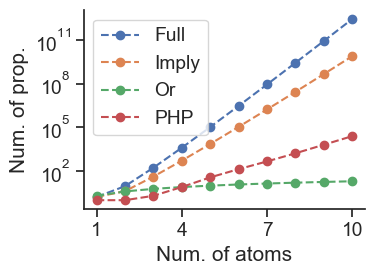

In [42]:
# width dimension

def full_width(n_nodes):
    n_ops = 3
    n_atoms = 3
    n_perms = math.perm(n_atoms, min(n_nodes, n_atoms))

#     n = n_nodes - 1
#     fac1 = 1 / (n + 1)
#     fac2 = math.comb(2 * n, n)
#     cat = fac1 * fac2

#     by_ops = n_ops**n * cat
#     by_atoms = (n_atoms + 2)**n_nodes * by_ops

    by_atoms = count_distinct_equations_assoc_comm(n_nodes, n_ops + 2)
    return by_atoms / n_perms


def imply_width(n_nodes):
    n_ops = 1
    n_atoms = 3
    n_perms = math.perm(n_atoms, min(n_nodes, n_atoms))

    n = n_nodes - 1
    fac1 = 1 / (n + 1)
    fac2 = math.comb(2 * n, n)
    cat = fac1 * fac2

    by_ops = n_ops**n * cat
    by_atoms = (n_atoms + 2)**n_nodes * by_ops
    return by_atoms / n_perms


def or_width(n_nodes):
    # return np.sum(np.arange(2, n_nodes + 2))
    return 2 * n_nodes # TODO: check more carefully


ls = np.arange(1, 11)
full_ws = [full_width(n) for n in ls]
# full_ws = [E[n] / 6 for n in ls]
imply_ws = [imply_width(n) for n in ls]
or_ws = [or_width(n) for n in ls]
php_ws = [php_width(n) for n in ls]

plt.gcf().set_size_inches(4, 3)
plt.plot(ls, full_ws, '--o', label='Full', color='C0')
plt.plot(ls, imply_ws, '--o', label='Imply', color='C1')
plt.plot(ls, or_ws, '--o', label='Or', color='C2')
plt.plot(ls, php_ws, '--o', label='PHP', color='C3')

# plt.axhline(1e6, color='C4', linestyle='--') <-- add if including PHP enum
# plt.axhline(36, linestyle='--', label='PHP', color='C3')

plt.yscale('log')
plt.xticks([1, 4, 7, 10])

plt.xlabel('Num. of atoms')
plt.ylabel('Num. of prop.')

plt.tight_layout()
plt.legend()

plt.savefig('pita_breadth.svg')


In [5]:
or_width(5)

np.int64(20)

In [3]:
ds = datasets.load_from_disk(full_text_ds_path)
ds

DatasetDict({
    True_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 202317
    })
    False_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 176243
    })
    True_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 157035
    })
    False_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 216163
    })
    True_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 165150
    })
    False_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 208434
    })
    True_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 154870
    })
    False_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
      

In [4]:
ds['False_5'][0]['completion'].count('</state>')

7

In [5]:
out = datasets.concatenate_datasets([d.select_columns(['completion']) for d in ds.values()])

In [6]:
out[-1]['completion'].count('</state>')

241

In [75]:
ds_configs = [
    {
        'name': 'Full',
        'path': full_text_ds_path
    },
    {
        'name': 'Imply',
        'path': imply_text_ds_path
    },
    {
        'name': 'Or',
        'path': or_text_ds_path
    },
    {
        'name': 'PHP',
        'path': php_enum_text_ds_path
    },
]

for config in ds_configs:
    print('Processing', config)
    ds_lens = []
    
    ds = datasets.load_from_disk(config['path'])
    ds.cleanup_cache_files()
    
    comp_ds = datasets.concatenate_datasets([d.select_columns(['completion', 'length']) for d in ds.values()])
    comp_ds = comp_ds.shuffle().select(range(500))
    
    def get_len(ex):
        # return ex['completion'].count('</state>')
        return ex['length']
    
    with Pool(24) as pool:
        ds_lens = pool.map(get_len, tqdm(comp_ds))
    
#     for k, v in ds.items():
#         name, num = k.split('_')
#         ds_lens.extend([int(num)] * len(v))
    
    config['lens'] = ds_lens

Processing {'name': 'Full', 'path': '~/workspace/imply/imply/task/prop_gen/data/hf_full_text'}


100%|██████████| 500/500 [00:00<00:00, 2779.74it/s]


Processing {'name': 'Imply', 'path': '~/workspace/imply/imply/task/prop_gen/data/hf_implies_text'}


100%|██████████| 500/500 [00:00<00:00, 582.66it/s]


Processing {'name': 'Or', 'path': '~/workspace/imply/imply/task/prop_gen/data/hf_or_text'}


100%|██████████| 500/500 [00:00<00:00, 552.72it/s]


Processing {'name': 'PHP', 'path': '~/workspace/imply/imply/task/prop_gen/data/hf_php_enum_text'}


100%|██████████| 500/500 [00:00<00:00, 6561.43it/s]


In [76]:
df = pd.DataFrame(ds_configs)
df = df.explode('lens')

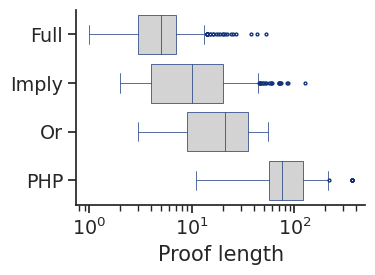

In [78]:
# mdf = df.sample(n=500)
mdf = df.copy()
g = sns.boxplot(mdf, y='name', x='lens', fliersize=2, color='lightgray', saturation=1, linecolor='#137', linewidth=0.5)
g.set_xscale('log')

g.set_xlabel('Proof length')
g.set_ylabel(None)

plt.tight_layout()
plt.savefig('pita_depth.svg')